This is a notebook to go through and analyze specific events.

In [1]:
import xarray as xr
from matplotlib import pyplot as plt
import numpy as np

data_path = "../../sliding_info_full_hour.nc"
ds = xr.open_dataset(data_path)


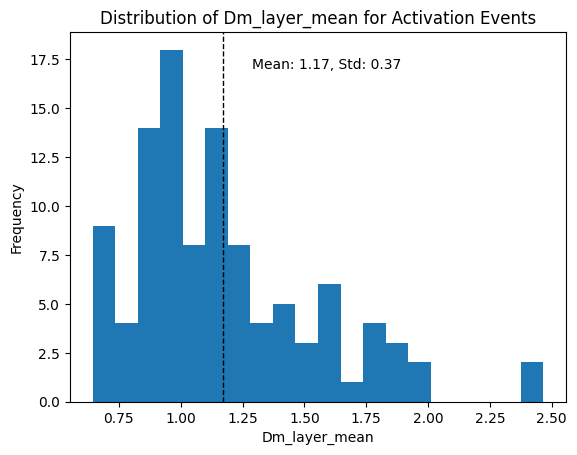

In [2]:
dsf = ds.where(ds["proc_label"] == "activation")["Dm_layer_mean"]
plt.hist(dsf.values.flatten(), bins=20)
plt.xlabel("Dm_layer_mean")
plt.ylabel("Frequency")
min_ylim, max_ylim = plt.ylim()

plt.axvline(dsf.mean(), color='k', linestyle='dashed', linewidth=1)
plt.text(dsf.mean()*1.1, max_ylim*0.9, f'Mean: {dsf.mean():.2f}, Std: {dsf.std():.2f}')

plt.title("Distribution of Dm_layer_mean for Activation Events")
plt.show()

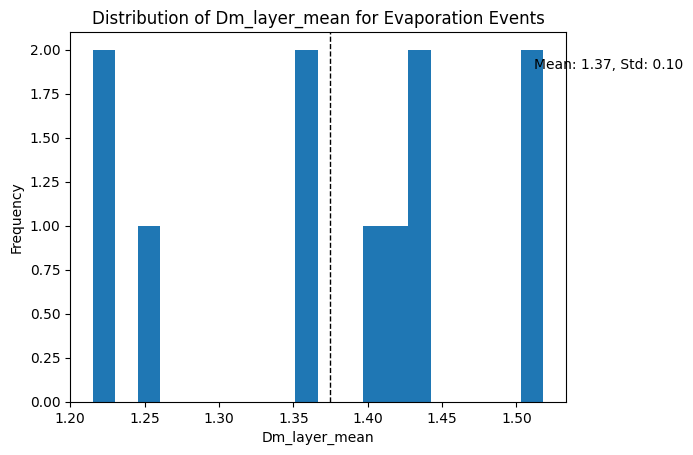

In [3]:
dsf = ds.where(ds["proc_label"] == "evaporation")["Dm_layer_mean"]
plt.hist(dsf.values.flatten(), bins=20)
plt.xlabel("Dm_layer_mean")
plt.ylabel("Frequency")
min_ylim, max_ylim = plt.ylim()

plt.axvline(dsf.mean(), color='k', linestyle='dashed', linewidth=1)
plt.text(dsf.mean()*1.1, max_ylim*0.9, f'Mean: {dsf.mean():.2f}, Std: {dsf.std():.2f}')

plt.title("Distribution of Dm_layer_mean for Evaporation Events")
plt.show()

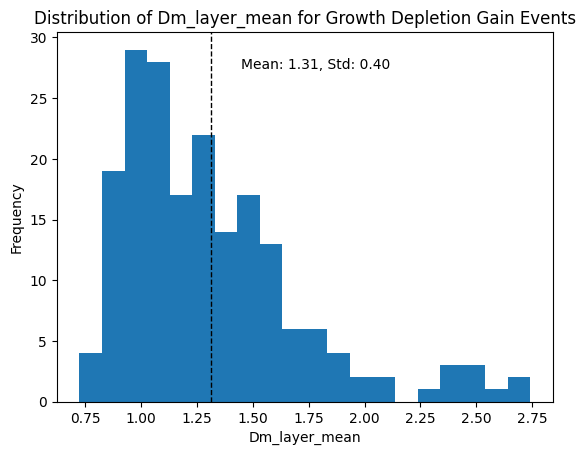

In [4]:
dsf = ds.where(ds["proc_label"] == "growth_depletion_gain")["Dm_layer_mean"]
plt.hist(dsf.values.flatten(), bins=20)
plt.xlabel("Dm_layer_mean")
plt.ylabel("Frequency")
min_ylim, max_ylim = plt.ylim()

plt.axvline(dsf.mean(), color='k', linestyle='dashed', linewidth=1)
plt.text(dsf.mean()*1.1, max_ylim*0.9, f'Mean: {dsf.mean():.2f}, Std: {dsf.std():.2f}')

plt.title("Distribution of Dm_layer_mean for Growth Depletion Gain Events")
plt.show()

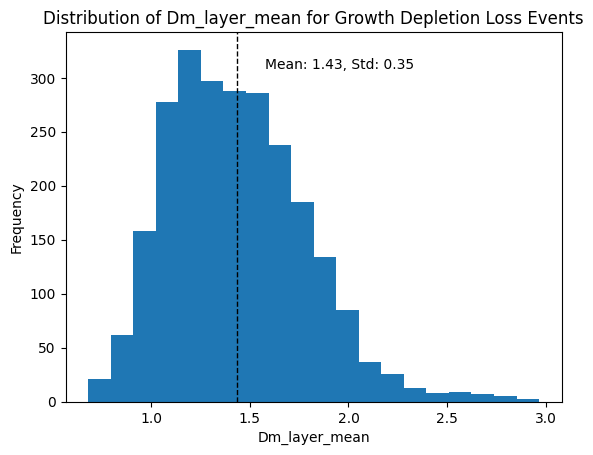

In [5]:
dsf = ds.where(ds["proc_label"] == "growth_depletion_loss")["Dm_layer_mean"]
plt.hist(dsf.values.flatten(), bins=20)
plt.xlabel("Dm_layer_mean")
plt.ylabel("Frequency")
min_ylim, max_ylim = plt.ylim()

plt.axvline(dsf.mean(), color='k', linestyle='dashed', linewidth=1)
plt.text(dsf.mean()*1.1, max_ylim*0.9, f'Mean: {dsf.mean():.2f}, Std: {dsf.std():.2f}')

plt.title("Distribution of Dm_layer_mean for Growth Depletion Loss Events")
plt.show()

Respectively, terminal velocities of: ~5.21m/s, 5.63m/s, 5.43m/s, 5.63m/s.
These are so close that I don't think the data show period changing at all.
Just to check:

In [6]:
# note: equations from https://codingace.net/physics/terminal_velocity_raindrop.html
from numpy.ma import std


def vt(m, g, pa, Cd, A):
    return np.sqrt((2 * m * g) / (pa * Cd * A))

def mass(pw, V):
    return pw * V

def volume(d):
    return (np.pi * d**3) / 6

def area(d):
    return (np.pi * (d**2)) / 4

pad = 1.225 # kg/m^3
pwd = 997 # kg/m^3
gd = 9.80665 # gravitational constant of earth
cdd = 0.47 # dmless

D_LIS = [1.17, 1.37, 1.31, 1.43]

print("Stats for mean diameters. values:")
for d in D_LIS:
    d /= 1000 # convert mm to m
    m = mass(pwd, volume(d))
    A = area(d)
    v = vt(m, gd, pad, cdd, A)
    print(f"D = {d}; v = {v:.2f} m/s; Period = {500/v:.2f} s")
print(f"Standard deviation of periods: {std([500/v for v in [vt(mass(pwd, volume(d)), gd, pad, cdd, area(d)) for d in [d/1000 for d in D_LIS]]]):.2f} s")


Stats for mean diameters. values:
D = 0.00117; v = 5.15 m/s; Period = 97.14 s
D = 0.0013700000000000001; v = 5.57 m/s; Period = 89.77 s
D = 0.00131; v = 5.45 m/s; Period = 91.81 s
D = 0.0014299999999999998; v = 5.69 m/s; Period = 87.87 s
Standard deviation of periods: 3.46 s


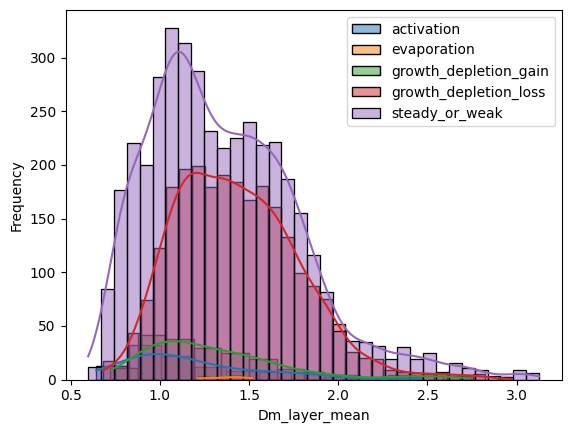

TypeError: cannot directly convert an xarray.Dataset into a numpy array. Instead, create an xarray.DataArray first, either with indexing on the Dataset or by invoking the `to_dataarray()` method.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

EVE_TYP = ["activation", "evaporation", "growth_depletion_gain", "growth_depletion_loss", "steady_or_weak"]
for i in EVE_TYP:
    values = ds.where(ds["proc_label"] == i)["Dm_layer_mean"].values.flatten()
    sns.histplot(
        x=values,
        bins=20,
        kde=True,
        stat="density",
        label=i,
        alpha=0.35,
    )

plt.xlabel("Dm_layer_mean")
plt.ylabel("Density")
plt.legend()
plt.show()